<a href="https://colab.research.google.com/github/voraciousnerd/iqm-quantum-school-labs/blob/main/2026_Summer_School_Day_2_Participants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Algorithms

Quantum computers can run algorithms that are not possible on a classical computer. In this notebook, you will learn how to:

* ...implement two quantum algorithms in qrisp,
* ...use qrisp to simulate the results,
* ...and execute them on an IQM quantum computer.

# Part 0: Setup

We'll prepare all our imports. This may take about a minute to load.

In [ ]:
from qrisp import *
from qrisp.interface import IQMBackend
from qrisp.grover import tag_state, grovers_alg

from iqm.qaoa.backends import SamplerResonance, SamplerSimulation
from iqm.applications.maxcut import MaxCutInstance
from iqm.qaoa.qubo_qaoa import QUBOQAOA
from iqm.applications.maxcut import maxcut_generator
from iqm.qaoa.circuits import qiskit_circuit

import os
import networkx as nx

Finally, we'll connect to an IQM Resonance quantum computer:

In [ ]:
token = input("IQM Resonance token: ")

iqm_server_url = os.environ.get("IQM_SERVER_URL", "https://resonance.iqm.tech")
quantum_computer = "garnet"  # Change to appropriate device name

iqm_device = IQMBackend(
    token=token,
    server_url = iqm_server_url,
    device_instance = quantum_computer)

# Part 1: Bernstein-Vazirani algorithm

The Bernstein-Vazirani algorithm is a quantum algorithm that solves the following problem:
> Given a hidden $n$-bit secret code $s$, and access to an oracle that computes the function $f(x) = s \cdot x$ (the dot product modulo 2), determine the secret code $s$ using as few queries to the oracle as possible.

$\renewcommand{\ket}[1]{\left| #1 \right\rangle}$
In order to implement the Bernstein-Vazirani algorithm, we will follow these steps:
1. **Initialization**: Prepare an $n$-qubit register (the "guess" or "input" qubits) in the state $\ket{0}^{\otimes n}$ .
2. **Hadamard Transform**: Apply the Hadamard gate to all qubits to create a superposition of all possible input states.
3. **Oracle Implementation**: Implement the oracle that encodes the secret code $s$ using an "answer" or "ancilla" qubit. The ancilla needs to be initialized in the state $
\frac{1}{\sqrt{2}}\left(\ket{0}-\ket{1}\right)$.
4. **Final Hadamard Transform**: Apply the Hadamard gate again to the $n$-qubit register.
5. **Measurement**: Measure the $n$-qubit register to obtain the secret code $s$.

### Steps 1 and 2

**Task 1: Fill in the code below to perform steps 1 and 2 in qrisp.**

In [ ]:
def initialize_and_Hadamard(length_of_secret_code):
    # TODO: Step 1: Initialize a quantum variable


    # TODO: Step 2: Apply Hadamard gates to all qubits


    return inputs

print(initialize_and_Hadamard(4)) #simulate the state for a length-4 secret code and print the probability for each outcome

### Step 3

Next up is the oracle.

An oracle is a black-box operation that encodes a function $f(x)$ into a quantum circuit. In the Bernstein-Vazirani algorithm, the oracle is designed to encode the secret code $s$ such that when it is applied to an input state $\ket{x}$, it produces a phase shift based on the dot product $s \cdot x$, that is, the number of bits where both $x$ and $s$ are `1` . Specifically, the oracle applies the transformation: $$U_f\ket{x} = (-1)^{s \cdot x}\ket{x}$$

For the Bernstein-Vazirani algorithm to be useful, you can't already know the secret code, which means that somebody else has to hand you the oracle. But in order to understand how this might work, you should try to make the oracle yourself!

**Task 2: Implement the Bernstein-Vazirani oracle that encodes the secret code $s$ using a controlled-X (CX) operation. Remember to use an "answer" or "ancilla" qubit (recommended: via an additional `QuantumVariable` inside the oracle function).**


In [ ]:
## Making an oracle - in a "useful" version of the algorithm, someone would hide this function from you.

# Step 3: Define a secret code and call the oracle

def oracle(qubits, secret_code):
    anc = QuantumVariable(1)
    # TODO: Implement the oracle!

    # You don't need to return the QuantumVariables.
    # You only have to return a QuantumVariable if it is 1) newly defined in the function and 2) you want to access it outside the function.
    # So we don't need to return qubits because it's not newly defined, and we don't need to return anc because we don't need access to it
    # elsewhere.

### Step 4

We just need to apply another round of Hadamard gates.

In [ ]:
# Step 4: Apply a final round of Hadamard gates
def final_Hadamards(qubits):
    #TODO: Implement this function!

### Putting it all together

Now we just combine our functions and add a measurement.

In [ ]:
def BernsteinVazirani(secret_code):
    length_of_secret_code = len(secret_code)
    qubits = initialize_and_Hadamard(length_of_secret_code)
    oracle(qubits, secret_code)
    final_Hadamards(qubits)
    measure(qubits)

    return qubits

secret_code='1001'
inputs = BernsteinVazirani(secret_code)

print(inputs)

If you want to see the circuit you have built so far, you can print the `QuantumSession` associated to your `QuantumVariable`:

In [ ]:
print(inputs.qs)

Now, use the IQM backend to execute the circuit and measure the qubits to retrieve the secret code.

In [ ]:
circuit = inputs.qs.compile()
job = iqm_device.run_async(circuit)
print(f"Job ID: {job.job_id}")
print(f"Results: {job.result().get_counts()}")

# Part 2: Variational Quantum Algorithms: QAOA and MaxCut

In this section, you will...


*   ...solve the MaxCut problem with QAOA by using the `iqm-qaoa` package to use QAOA.
*   ...experiment with the built-in functions of `iqm-qaoa`.

Recall that the MaxCut problem is the following:

Suppose that you have $N$ students who are taking an exam. You must assign each student to take the exam in one of two rooms, which we will call room $0$ and room $1$. Students who are friends and in the same room are more likely to cheat. Your goal is to minimize the chance of cheating by separating as many pairs of friends as possible. Assume you know the friendships.

### Setting up the problem

In principle, once we set up the graph of friendships, the whole problem is set up, because the cost function and the QAOA ansatz are both determined by the friendship graph.

Conveniently, if we build the graph as a `networkx` object, `iqm-qaoa` contains all sort of nice functions to create everything else we want to solve the problem and benchmark our solutions.

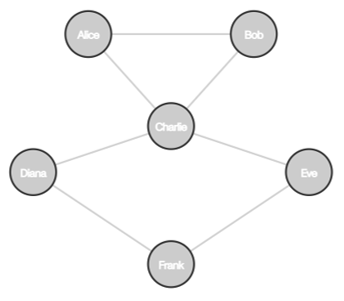

**Task: Construct the friendship graph above ([which you played with in lecture here](https://www.iqmacademy.com/explore/maxcut/)).**

In [ ]:
G = nx.Graph()
# TODO: Specify the edges as a list of pairs. For example, if nodes 1 and 5 have
# an edge between them, include [1,5] in the list.
graph_edges = [[]]

G.add_edges_from(graph_edges)
MaxCut_instance = MaxCutInstance(G)
MaxCut_instance.draw_problem()

This `MaxCutInstance` specifies a problem. Remember from lecture that when we try to **solve** the problem, we have a few choices to make. Most importantly, we have to choose a number of "layers" of the QAOA ansatz to apply.

Recall that the ith layer of the QAOA ansatz applies the circuit
$$e^{-i\beta_i H_{mix}}e^{-i \gamma_i H_c}$$
to the qubits, where the variational parameters are $\beta_i$ and $\gamma_i$. So, the number of variational parameters in QAOA is twice the number of layers.

We're going to be optimizing (also known as `train`ing) the $\beta_i$ and $\gamma_i$, but the optimizer needs to have some initial guesses for these parameters. We can choose whatever values we like.

The number of layers and initial guesses need to get combined with the problem statement to make the full QAOA ansatz. We can then use the `train` method to optimize the parameters.

In principle, the `train` process can be done on a quantum computer, but in practice this is often unnecessary. It turns out that for special classes of problems, including this one, there are efficient classical ways to optimize the ansatz. Why, then, do we need the quantum computer at all? The thing that is still difficult classically is to take the state with its optimized parameters and find the probabilities of getting all of the possible output measurements. Ideally, the most probable output is the correct answer.

For now, we'll just `train` classically. By default, this method uses analytical formulas if the QAOA has one layer and a simulator otherwise.

In [ ]:
layers = 1
parameter_guesses = [0.1,0.2]

MaxCut_qaoa = QUBOQAOA(problem=MaxCut_instance, num_layers=1,
                       initial_angles=parameter_guesses)
MaxCut_qaoa.train()

We can also print the circuit, where we see that there is indeed a ZZ-Gate between qubits for every edge in graph, followed by an RX-Gate on every qubit.

In [ ]:
qiskit_qc = qiskit_circuit(MaxCut_qaoa, measurements=True)   # measurements=True by default
qrispqc = QuantumCircuit.from_qiskit(qiskit_qc)
print(qrispqc)                    # ASCII art

### Running QAOA


Finally, we can sample the resulting state using the quantum computer (if you kept the sampler as the quantum computer above). We can then process the output.

We'll see here a nice feature of `iqm-qaoa`: our `MaxCutInstance` has a `quality()` method, which accepts as input an assignment of students to rooms. It ouputs the cost for that assignment.

In [ ]:
samples = qrispqc.run(backend=iqm_device,shots=20000)
print(samples)

most_probable = max(samples, key=lambda y: samples[y])
most_probable_cost = MaxCut_instance.quality(most_probable)
print("Cost of most probable coutcome: ", most_probable_cost)
print("Most probable outcome :", most_probable)

**Task: Interpret the output you get. How did the algorithm assign rooms to the students? Does it match the optimal result we found in lecture?**

We can also calculate the cost of different outputs and compare them with the optimal cost, which is calculated for you by `iqm-qaoa` using classical brute force. This is very useful for benchmarking QAOA for small problems. For large problems, of course, the whole point is that MaxCut is classically hard, so it's not feasible to calculate this classically.

In [ ]:
print("Optimal cost: ", MaxCut_instance.lower_bound) #Classically obtain the best possible cost by brute force

# Calculate the cost function of all found solutions
samples_cost = {sample: MaxCut_instance.quality(sample) for sample in samples}

# Find the sample with the best quality
best_sample = min(samples_cost, key=lambda y: samples_cost[y])

# Find the best quality
best_quality = samples_cost[best_sample]

print("Best sample found by QAOA: ", best_sample)
print("Best cost found by QAOA: ", best_quality)

### Using some built-in MaxCut functionality

The IQM QAOA package has a lot of functionality that automates creating and solving MaxCut problems. It can generate random instances of MaxCut using `maxcut_generator`, solve them classically, and solve them with QAOA for comparison. Below is a code snippet for this.

In [ ]:
problem_size=14 # Number of nodes (students) in the graph. Some of the later code will be slow if this is above 30 or so.

# The next line returns a MaxCut problem which can be used just like our previous ConstrainedQuadraticInstance
random_MaxCut = next(maxcut_generator(n=problem_size, n_instances=1))
random_MaxCut.draw_problem()

# Classically obtain the best possible cost by brute force
print("Optimal cost: ", random_MaxCut.lower_bound)

random_MaxCut_QAOA = QUBOQAOA(problem=random_MaxCut, num_layers=1, initial_angles=[0.1,0.2])
random_MaxCut_QAOA.train()

random_graph_qc = qiskit_circuit(random_MaxCut_QAOA, measurements=True)   # measurements=True by default
random_graph_qrisp = QuantumCircuit.from_qiskit(random_graph_qc)
randomGraph_samples=random_graph_qrisp.run(backend=iqm_device,shots=20000)

# Printing all the samples is going to be too much! Don't do that.

# Find the most probable sample
most_probable = max(randomGraph_samples, key=lambda x: randomGraph_samples[x])
print("Most probable outcome :", most_probable)

randomGraph_samples_cost = {sample: random_MaxCut.quality(sample) for sample in randomGraph_samples}

# Find the sample with the best quality
randomGraph_best_sample = min(randomGraph_samples_cost, key=lambda x: randomGraph_samples_cost[x])

# Find the best quality
randomGraph_best_quality = randomGraph_samples_cost[randomGraph_best_sample]

# Find the cost of the most probable outcome
randomGraph_mostProbable_quality = randomGraph_samples_cost[most_probable]

print("Cost of the most probable outcome: ", randomGraph_mostProbable_quality)
print("Lowest cost outcome found by QAOA: ", randomGraph_best_sample)
print("Best cost found by QAOA: ", randomGraph_best_quality)

# Homework: Grover's algorithm

Grover's algorithm is a quantum algorithm that solves the following problem:
> Given a function $f:\{0,1\}^n \rightarrow \{0,1\}$ that outputs 1 for a single input $x_0$ (the "marked" item) and 0 for all other inputs, find the marked item $x_0$ using as few queries to the function as possible.

In the context below, we'll use 0 to represent "false" and 1 to represent "true."

Our goal is to implement Grover's algorithm to find the input that satisfies the following Boolean formula (a "SAT problem"):
$$ (x_0 \text{ OR } x_1) \text{ AND } (\neg x_0 \text{ OR } x_1)  \text{ AND } (x_0 \text{ OR } \neg x_1)$$

Remember that $\neg x_1$ means NOT $x_1$. $\neg x_1$ is true when $x_1$ is false.

Each piece in parentheses is called a "clause", and each variable (either $x_i$ or $\neg x_i$) inside the clause is called a "literal."

We represent the possible solutions (possible true/false values for $x_0$ and $x_1$) with 2 "register" qubits, where $\ket{00}$ represents both variables being false, $\ket{10}$ represents $x_0$ true and $x_1$ false, and so on.

Grover's algorithm consists of the following steps:

1.    **Intialization:**   Prepare two register qubits, one ancilla per clause, and one extra ancilla. The final ancilla should be prepared in the state $\ket{-}$, and the rest in state $\ket{0}$.
2.   **Apply Hadamards**: Apply a Hadamard gate to every register qubit, which gives us quantum parallelism (i.e., means we're inputting a superposition of all possible solutions)
3.   **Oracle Implementation**: Apply the oracle, which "tags" the correct solution by flipping the sign of its amplitude
4.   **Diffusion Operator**: Apply the "diffusion operator", which increases the probability of measuring the tagged state
5.   **Repeat**: Repeat steps 3 and 4 until another repeat would instead decrease the probability of measuring the tagged state.
6.   **Measure Register Qubits**: The most probable measurement outcome is the solution.


## Task: Implement Grover's algorithm

**Step 1: Initialize a quantum variable and Hadamard transform all but the ancillary qubits.**

In [ ]:
def grover_initialize_and_Hadamard():
    ## Create a quantum variable with two qubits, representing x0 and x1, and one for the ancillary qubits (one qubit per clause and one additional ancilla)
    qv = QuantumVariable(2)
    ancillas = QuantumVariable(4)

    # TODO: Prepare the final ancilla in the |-⟩ state


    ## TODO: Step 1: Apply single-qubit Hadamard gates to the non-ancilla qubits


    return qv, ancillas

#Check that the output looks right
testqv, testancillas = grover_initialize_and_Hadamard()
print(testqv.qs)
print(testqv)
print(testancillas.qs)
print(testancillas)


**Step 2: Define the oracle.**

 An oracle is a black-box operation that encodes a function $f(x)$ into a quantum circuit. In Grover's algorithm, the oracle is designed to mark the solution state by flipping its amplitude. Specifically, the oracle applies the transformation: $$U_f\ket{x} = (-1)^{f(x)}\ket{x}$$ where $f(x) = 1$ for the marked item and $f(x) = 0$ for all other items.

 We'll design our oracle in the following way. Ancilla $i$ should be set to $1$ if clause $i$ is false. Then we flip the final ancilla (which gives us the desired minus sign) if all of the ancillas are $0$ (that is, if all of the clauses are true).

In [ ]:
# Define the oracle
def apply_oracle(q, ancillas):

    # Clause x0 OR x1 - this code flips ancilla 0 if (x0 OR x1) is false
    x(q[0]) # Negate x0
    x(q[1]) # Negate x1
    mcx(q, ancillas[0]) # multi-controlled X gate - flip ancilla 0 if all of the q qubits are 1
    x(q[0]) # Reapply X to x0
    x(q[1]) # Reapply X to x1

    # TODO: Add the circuits for the other clauses

    # clause (NOT x0) OR x1 - flip ancilla 1 if ((NOT x0) OR x1) is false



    # clause x0 OR (NOT x1) - flip ancilla 2 if (x0 OR (NOT x1)) is false



    #Flip the final ancilla if all the clauses are true



    # Right now the ancillas are entangled with the data qubits. It turns out this messes up our diffusion operator. So we need to
    # "uncompute" the ancillas, that is, return them to their original state.

    # Uncompute ancilla 0 by undoing the flip we applied earlier
    x(q[0])
    x(q[1])
    mcx(q, ancillas[0])
    x(q[0])
    x(q[1])

    # TODO: uncompute the other ancillas

    # Uncompute ancilla 1



    # Uncompute ancilla 2



**Step 3: Define the diffusion operator**

The diffusion operator has the effect of "mirroring" the amplitudes with respect to the average. In particular, it turns the state
$$\ket{\psi}=\sum_x a_x \ket{x}$$
into the state
$$\ket{\psi}=\sum_x (2\overline{a}-a_x)\ket{x}$$
where $\overline{a}$ is the average of all of the $a_x$.

The effect of this operator in the context of Grover's algorithm is to enhance the probability of the "tagged" state, which is the only state $\ket{x}$ with a negative amplitude $a_x$.

One can mathematically prove that the operator we want is exactly the same as the following: apply Hadamard gates to all of the registers. Then apply an oracle that tags the state where all of the qubits are $0$. Finally, apply Hadamard gates to all of the registers again.

In [ ]:
# Define the diffusion operator
def apply_diffusion(q, ancillas):
    # TODO: implement the diffusion operator. HINT: the gate mcx(controls, targets) flips the target if all of
    # the controls are 0.

    pass


**Step 4: Run the algorithm**

With both components defined, we can construct the full Grover's algorithm circuit by alternating between the oracle and diffusion operator for a specified number of iterations. Finally, we measure the qubits to obtain the result, which should yield the marked item with high probability.

In [ ]:
def run_Grover(iterations):
    # Apply the oracle and the diffusion operator for the required number of iterations
    qv, ancillas = grover_initialize_and_Hadamard()
    for _ in range(iterations):
        apply_oracle(qv,ancillas)
        apply_diffusion(qv,ancillas)
    return qv, ancillas

iteration_count = 1
qv, ancillas = run_Grover(iteration_count)
# Output the quantum circuit
print(qv.qs)
print(qv)

Now, use the IQM backend to execute the circuit and measure the qubits to retrieve the marked item.

In [ ]:
print(qv.get_measurement(backend = iqm_device))



**Task: Repeat the experiment with a different SAT formula (make a new oracle!) and check the results.**

### Using the qrisp Grover library

qrisp comes equipped with a Grover's algorithm library that simplifies the implementation process. You can use the `grover_alg` function to create a Grover's search circuit with minimal effort. `tag_state` allows you to specify the state you want to search for easily, so the oracle becomes a one-liner.

The code below shows how to use qrisp's built-in functions to implement Grover's algorithm. Read through, understand the code, and run it!

In [ ]:
# Define the oracle
# This oracle tags the state |2> by changing its phase by pi.
def oracle(qv, phase = np.pi):
    tag_state({qv : 2}, phase = phase)

# Define the QuantumFloat representing the search space
n = 3
qf = QuantumFloat(n)

# Execute Grover's algorithm
grovers_alg(qf,
            oracle,
            exact = True,
            winner_state_amount = 1)

# Retrieve the measurements
simulator_res = qf.get_measurement()
print("Simulator result: ", simulator_res)

meas_res = qf.get_measurement(backend = iqm_device)
print("Device result: ", meas_res)


In [ ]:
# Copyright 2025 IQM Quantum Computers (Stefan Seegerer, Daniel Bulmash)
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.